# set up

In [1]:
import sys
if sys.platform == 'linux':
    sys.path.append("/home/qix/MultiNeuronGLM")
else:
    sys.path.append("D:/Github/MultiNeuronGLM")

In [2]:
import pandas as pd
import utility_functions as utils
import GLM
from DataLoader import Allen_dataset
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import numpy as np
sns.set_theme()

In [3]:
# Use self trained K-means results, which have a better likelihood
import pickle
with open('group_id_all_a_c/membership.pickle', 'rb') as handle:
    membership = pickle.load(handle)
with open('group_id_all_a_c/condition_ids.pickle', 'rb') as handle:
    condition_ids = pickle.load(handle)

# (failed) Adding population refractory term

## Set up

In [4]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Decide history effect tau

### probeA

In [250]:
tau_list = np.logspace(np.log10(1), np.log10(100), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeA', tau=tau)
    model.fit('probeA', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

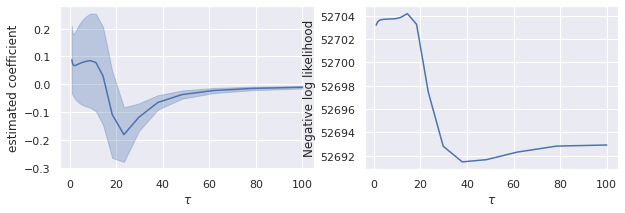

In [251]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### probeB

In [252]:
tau_list = np.logspace(np.log10(1), np.log10(100), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeB', tau=tau)
    model.fit('probeB', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

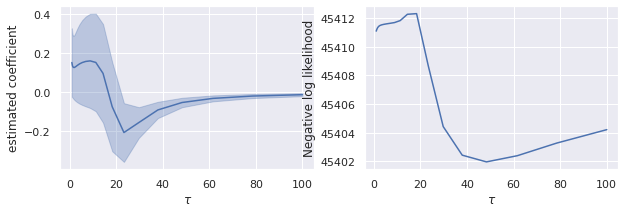

In [253]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### probeC

In [254]:
tau_list = np.logspace(np.log10(1), np.log10(100), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeC', tau=tau)
    model.fit('probeC', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

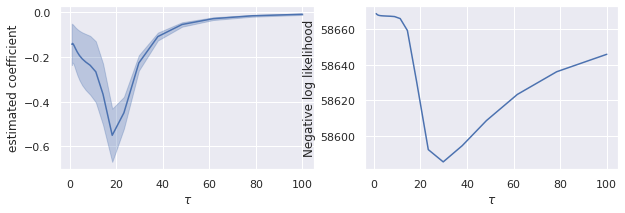

In [255]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### probeD

In [256]:
tau_list = np.logspace(np.log10(1), np.log10(100), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeD', tau=tau)
    model.fit('probeD', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

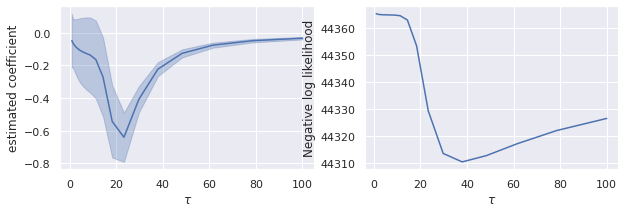

In [257]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### probeE

In [258]:
tau_list = np.logspace(np.log10(1), np.log10(100), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeE', tau=tau)
    model.fit('probeE', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

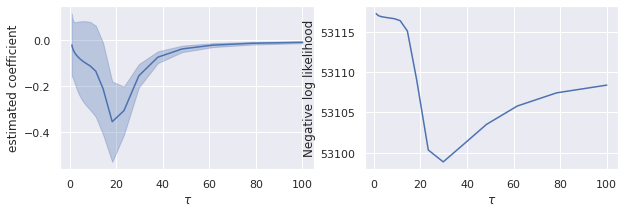

In [259]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### probeF

In [260]:
tau_list = np.logspace(np.log10(1), np.log10(200), 20)

para_list = []
bse_list = []
nll_list = []
for i, tau in enumerate(tau_list):
    best_time_diff = 100
    smooth_std = 20
    num_basis_baseline = 30
    num_varying_linear = 30

    probe_list = V1.selected_probes
    select_trials = np.full(V1.ntrial, True)

    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

    trial_state = np.zeros_like(V1.speed)
    for i in range(trial_state.shape[1]):
        if V1.running_trial_index[i]:
            trial_state[:,i] = 1.0

    model.add_effect('varying_linear', trial_state, num=num_varying_linear)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
    model.add_effect('trial_coef')
    model.add_effect('refractory', 'probeF', tau=tau)
    model.fit('probeF', verbose=False)
    para_list.append(model.results.params[-1])
    bse_list.append(model.results.bse[-1])
    nll_list.append(model.nll)
    

Text(0, 0.5, 'Negative log likelihood')

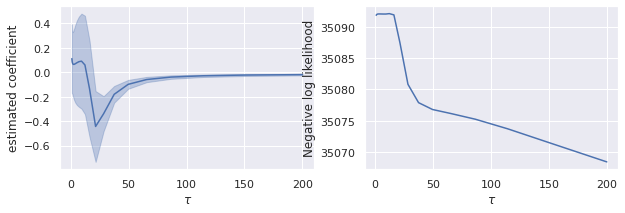

In [261]:
x = np.array(tau_list)
y = np.array(para_list)
ci = np.array(bse_list)

plt.subplots(figsize=(10,3))
plt.subplot(1,2,1)
plt.plot(x, y, color='b')
plt.fill_between(x, (y-2*ci), (y+2*ci), color='b', alpha=.3)
plt.xlabel(r'$\tau$')
plt.ylabel(r'estimated coefficient')
plt.subplot(1,2,2)
plt.plot(tau_list, nll_list, color='b')
plt.xlabel(r'$\tau$')
plt.ylabel(r'Negative log likelihood')

### just some test space

In [239]:
# Use for test
best_time_diff = 100
smooth_std = 20
num_basis_baseline = 30
num_varying_linear = 30
tau = 30

probe_list = V1.selected_probes
# select_trials = np.full(V1.ntrial, True)
# select_trial = V1.stationary_trial_index
select_trial = V1.running_trial_index

model = GLM.PP_GLM(dataset=V1, 
                   select_trials=select_trials, 
                   membership=membership, 
                   condition_ids=condition_ids)
model.add_effect('inhomogeneous_baseline', num=num_basis_baseline)

for j, input_probe in enumerate(probe_list):
    model.add_effect('coupling', probe_list[j], peaks_max=50, num=8, nonlinear=0.3)
model.add_effect('refractory', 'probeC', tau=tau)
model.fit('probeC', verbose=True)

Negative log likelihood is: 32096.18
aic/2 is: 32175.18


# Fit

## Set up

probeA = AM, probeB = PM, probeC = V1, probeD = LM, probeE = AL, probeF = RL

In [4]:
# Load LFP data
start_time = 0.0
end_time = 0.50
padding = 0.3
V1 = Allen_dataset(fps=1000,
                   start_time=start_time, 
                   end_time=end_time,
                   padding=padding,
#                    orientation=[0],
                   session_id=757216464,
                   selected_probes=['probeA', 'probeB', 'probeC', 'probeD', 'probeE', 'probeF'],
#                    temporal_frequency=[1,2,4],
                   stimulus_condition_id=[275, 277, 246, 255, 272, 248, 283, 266, 274, 276, 286, 271, 268, 270],
                   stimulus_name='drifting_gratings')

# V1.get_lfp()
# V1.remove_padding(padding)
V1.get_trial_metric_per_unit_per_trial()
# V1.get_trial_metric_per_unit_per_trial(metric_type='spike_times')
V1.get_running(method="mine")

/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/stimulus_table/naming_utilities.py:154: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  movie_rows = table[stim_colname].str.contains(movie_re, na=False)
/home/qix/anaconda3/lib/python3.9/site-packages/allensdk/brain_observatory/ecephys/ecephys_session.py:1315: UserWarning: Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',Spikes within these intervals are invalid and may need to be excluded from the analysis.
  warnings.warn("Session includes invalid time intervals that could be accessed with the attribute 'invalid_times',"


## Fit

In [6]:
num_basis_baseline = 30
coupling_filter_params = {'peaks_max':50, 'num':6, 'nonlinear':0.3}
# use_all = [True, True, False, False, False, True]
use_all = [False, False, False, False, False, False]
tau_list = [30, 30, 20, 25, 22, 10]

probe_list = V1.selected_probes
running_filter = {}
stationary_filter = {}
running_model_list = []
stationary_model_list = []

for i, target_probe in enumerate(probe_list):
    select_trials = V1.running_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
#     model.add_effect('trial_coef')
#     model.add_effect('refractory', probe_list[i], tau=tau_list[i])
    model.fit(probe_list[i], verbose=False)
    running_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    running_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        running_filter[i,j] = filter_list[k]
        k += 1
    
    select_trials = V1.stationary_trial_index
    model = GLM.PP_GLM(dataset=V1, 
                       select_trials=select_trials, 
                       membership=membership, 
                       condition_ids=condition_ids)
    model.add_effect('inhomogeneous_baseline', num=num_basis_baseline, add_constant_basis=False)
    for j, input_probe in enumerate(probe_list):
        model.add_effect('coupling', probe_list[j], use_all=use_all[j], **coupling_filter_params)
#     model.add_effect('trial_coef')
#     model.add_effect('refractory', probe_list[i], tau=tau_list[i])
    model.fit(probe_list[i], verbose=False)
    stationary_model_list.append(model)
    filter_list = model.get_filter(ci=True)
    stationary_filter[i,-1] = filter_list[0]
    k = 1
    for j, input_probe in enumerate(probe_list):
        stationary_filter[i,j] = filter_list[k]
        k += 1
    

## Plot

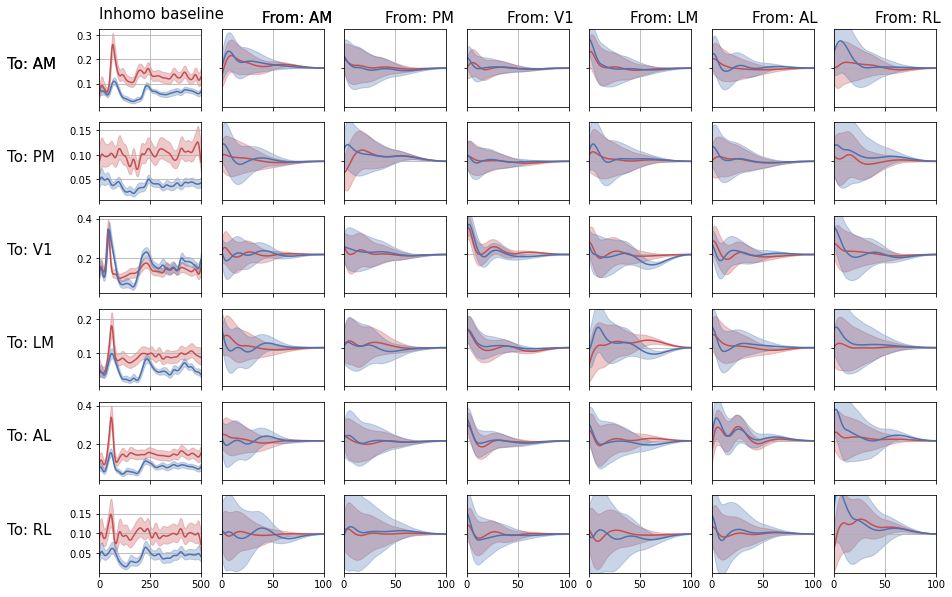

In [294]:
# use_all are all False
name_list = ['AM', 'PM', 'V1', 'LM', 'AL', 'RL']
fontsize = 15

sns.reset_orig()
# sns.set_theme()
plt.subplots(figsize=(15,10))
for i in range(len(probe_list)):
    for j in range(-1, len(probe_list)):
        ax = plt.subplot(6, 7, i*7+j+1+1, frameon=True)
        filter_index = i,j
        y, ci = running_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='running', color='r')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='r', alpha=.3)
        else:
            plt.plot(x, y,label='running', color='r')
            plt.fill_between(x, y-2*ci, y+2*ci, color='r', alpha=.3)
            
        y, ci = stationary_filter[filter_index]
        x = np.arange(y.shape[0])
        if j == -1:
            plt.plot(x, np.exp(y),label='stationary', color='b')
            plt.fill_between(x, np.exp((y-2*ci)), np.exp((y+2*ci)), color='b', alpha=.3)
            plt.xticks([0, 250, 500])
            plt.xlim([0, 500])
            
        else:
            plt.plot(x, y,label='stationary', color='b')
            plt.fill_between(x, y-2*ci, y+2*ci, color='b', alpha=.3)
            plt.yticks([0])
            plt.ylim([-0.17, 0.17])
            plt.yticks(color='w')
            plt.xticks([0, 50, 100])
            plt.xlim([0, 100])
            if i==0:
                plt.text(40, 0.2, f'From: {name_list[j]}', fontsize=fontsize)
                
        if j==0:
            plt.text(-210, 0, f'To: {name_list[i]}', fontsize=fontsize)
        if i != 5:
            plt.xticks(color='w')
        plt.grid()
        
        if i==0 and j==2:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(-450, 0, f'To: AM', fontsize=fontsize)
        if i==1 and j==0:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(40, 0.61, f'From: AM', fontsize=fontsize)
        if i==0 and j==-1:
            plt.subplot(6, 7, i*7+j+1+1, frameon=True)
            plt.text(0, 0.37, f'Inhomo baseline', fontsize=fontsize)



# Simulation

In [13]:
tau = 20
refractory_stength = 10
model_list = running_model_list

import copy
import numpy.random
nneuron = len(model_list)
# Get three dimension matrix of coupling filters for better computing. 
max_histories = 1
nt = model_list[0].nt
# allowed_effect_type = ['inhomogeneous_baseline', 'coupling']
allowed_effect_type = ['inhomogeneous_baseline', 'coupling', 'trial_coef']
coupling_mat = np.zeros((max_histories, nneuron, nneuron))
baseline_mat = np.zeros((nt, nneuron))
spikes = np.zeros((nt, nneuron, 1))
probe2num = {}
for iprobe, probe in enumerate(probe_list):
    probe2num[probe] = iprobe

for ineuron in range(nneuron):
    assert all(effect_type in allowed_effect_type for effect_type in model_list[ineuron].effect_type_list), "Only support inhomogeneous_baseline and coupling effects now!"
    model = model_list[ineuron]
    for ieffect, effect_type in enumerate(model.effect_type_list):
        
        if effect_type in ['inhomogeneous_baseline']:
            baseline_mat[:, ineuron] = model.filters[ieffect]
        elif effect_type in ['coupling']:
            nhistories = len(model.filters[ieffect])
            probe_name = utils.PROBE_CORRESPONDING_INVERSE[model.basis_name[ieffect][-2:]]
            iprobe = probe2num[probe_name]
            if nhistories > max_histories:
                coupling_mat_old = coupling_mat
                coupling_mat = np.zeros((nhistories, nneuron, nneuron))
                coupling_mat[-max_histories:, :, :] = coupling_mat_old
                max_histories = nhistories
            coupling_mat[-nhistories:, iprobe, ineuron] = np.flip(model.filters[ieffect])

log_firing_rate = baseline_mat[:,:,np.newaxis]
spikes[0,:,0] = np.random.poisson(np.exp(log_firing_rate[0,:,0]))

recent_spike_sum = spikes[0, :, 0]

for t in range(1, nt):
    recent_spike_sum *= np.exp(-1000.0/V1.fps/tau)
    nhistories = min(t, max_histories)
    temp_log_firing_rate = (coupling_mat[-nhistories:, :, :] * spikes[(t-nhistories):(t), :, :]).sum(axis=(0, 1))
    log_firing_rate[t,:,0] = temp_log_firing_rate - refractory_stength*recent_spike_sum
    spikes[t,:,0] = np.random.poisson(np.exp(log_firing_rate[t,:,0]))
    
    recent_spike_sum += spikes[t, :, 0]

log_firing_rate = log_firing_rate.squeeze()
spikes = spikes.squeeze()